🏎️ **F1 Machine Learning Project — Simulación y Predicción de Carrera**


Este proyecto tiene como objetivo construir un sistema de Machine Learning aplicado a la Fórmula 1 🏁, capaz de:


  - 📊 Predecir tiempos de vuelta
  - 🧠 Modelar el rendimiento de pilotos y equipos
  - 🚀 Simular carreras completas vuelta a vuelta
  - 🏆 Generar clasificaciones y campeonatos simulados
  - 📡 Origen de los datos


Los datos utilizados en este proyecto han sido obtenidos mediante la API de FastF1, una librería especializada en la extracción de datos reales de Fórmula 1.

📁 **Estructura de obtención de datos**

Los archivos del proyecto están organizados en varias descargas:

  - descarga1.py
  - descarga2.py
  - descarga3.py
  - descarga4.py

Estos scripts son los encargados de conectarse a la API de FastF1 y descargar los datos históricos de carreras, pilotos, equipos y vueltas.

⚠️** Importante**

Estos scripts NO deben ejecutarse durante el análisis principal del notebook, ya que:

  - ⏱️ Las llamadas a la API pueden tardar mucho tiempo
  - 🌐 Dependen de conexión a internet y rate limits
  - 📉 Pueden ralentizar o interrumpir el flujo del proyecto

Por este motivo, los datos ya fueron descargados previamente y se trabaja directamente con los archivos .csv generados 📂.

🧠 **Enfoque del proyecto**

El pipeline completo incluye:

  - 🧹 Limpieza y preprocesado de datos
  - ⚙️ Ingeniería de features avanzadas (carga aerodinámica, degradación de neumáticos, históricos de pilotos…)
 -  🤖 Modelos de Machine Learning (XGBoost principalmente)
  - 🏁 Simulación de carreras completas
  - 📈 Visualización de resultados y campeonatos

🎯 **Objetivo final**

Construir un sistema capaz de aproximar el rendimiento real de la F1 usando Machine Learning, combinando datos históricos, características técnicas y simulación probabilística.

📦 **Librerías**

Se importan las librerías necesarias para el análisis, preprocesado, modelado y visualización de datos.

🧠 **exploracion**

exploracion es una librería personalizada creada por mí para realizar el análisis exploratorio de datos (EDA) de forma más rápida y automatizada (nulos, duplicados, resumen de datasets, etc.).

In [ ]:
import pandas as pd
import numpy as np
import exploracion as exp
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')



📁 **Carga de datos**

En esta parte se cargan los datasets del proyecto desde distintos archivos .csv.

Debido al tiempo elevado de descarga desde la API de FastF1, los datos se dividieron en varias partes durante el proceso de obtención.

In [ ]:
df_resultados_2024_1 = pd.read_csv('resultados_2024_1.csv')
df_resultados_2024_2 = pd.read_csv('resultados_2024_2.csv')
df_resultados = pd.concat([df_resultados_2024_1, df_resultados_2024_2])

df_laps_2024_1 = pd.read_csv('laps_2024_1.csv')
df_laps_2024_2 = pd.read_csv('laps_2024_2.csv')



df_laps_all = pd.concat([df_laps_2024_1, df_laps_2024_2])
df_laps = df_laps_all[df_laps_all['TrackStatus'] == 1].copy()

df_pilotos_2024_1 = pd.read_csv('pilotos_2024_1.csv')
df_pilotos_2024_2 = pd.read_csv('pilotos_2024_2.csv')
df_pilotos = pd.concat([df_pilotos_2024_1, df_pilotos_2024_2])

df_equipos    = pd.read_csv('equipos_2024_1.csv')
df_calendario = pd.read_csv('schedule_2024.csv')

print(df_equipos.head(5))
print(df_pilotos.head(5))
print(df_calendario.head(5))
print(df_laps.head(5))
print(df_resultados.head(5))

       TeamName TeamColor        TeamId
0        Alpine    ff87bc        alpine
1  Aston Martin    229971  aston_martin
2       Ferrari    e8002d       ferrari
3  Haas F1 Team    b6babd          haas
4   Kick Sauber    52e252        sauber
   DriverNumber BroadcastName Abbreviation        DriverId         TeamName  \
0             1  M VERSTAPPEN          VER  max_verstappen  Red Bull Racing   
1            11       S PEREZ          PER           perez  Red Bull Racing   
2            55       C SAINZ          SAI           sainz          Ferrari   
3            16     C LECLERC          LEC         leclerc          Ferrari   
4            63     G RUSSELL          RUS         russell         Mercedes   

  TeamColor    TeamId FirstName    LastName         FullName  ... Position  \
0    3671c6  red_bull       Max  Verstappen   Max Verstappen  ...      1.0   
1    3671c6  red_bull    Sergio       Perez     Sergio Perez  ...      2.0   
2    e8002d   ferrari    Carlos       Sainz     Car

🔍 **EDA automático**

Se agrupan los principales DataFrames en un diccionario para analizarlos de forma conjunta.

Se utiliza la librería personalizada exploracion para automatizar el análisis exploratorio:

  - 📌 resumen del dataset
  - ❌ valores nulos
  - 🔁 duplicados
  - 📭 filas vacías
  - 📊 outliers

RESULTADOS 2024
Numero de registros:
479
Numero de columnas:
25
Tipos de Datos:
DriverNumber            int64
BroadcastName          object
Abbreviation           object
DriverId               object
TeamName               object
TeamColor              object
TeamId                 object
FirstName              object
LastName               object
FullName               object
HeadshotUrl            object
CountryCode            object
Position              float64
ClassifiedPosition     object
GridPosition          float64
Q1                    float64
Q2                    float64
Q3                    float64
Time                   object
Status                 object
Points                float64
Laps                  float64
Season                  int64
GrandPrix              object
Session                object
dtype: object
Información:
<class 'pandas.core.frame.DataFrame'>
Index: 479 entries, 0 to 139
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dt

/content/exploracion.py:56: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


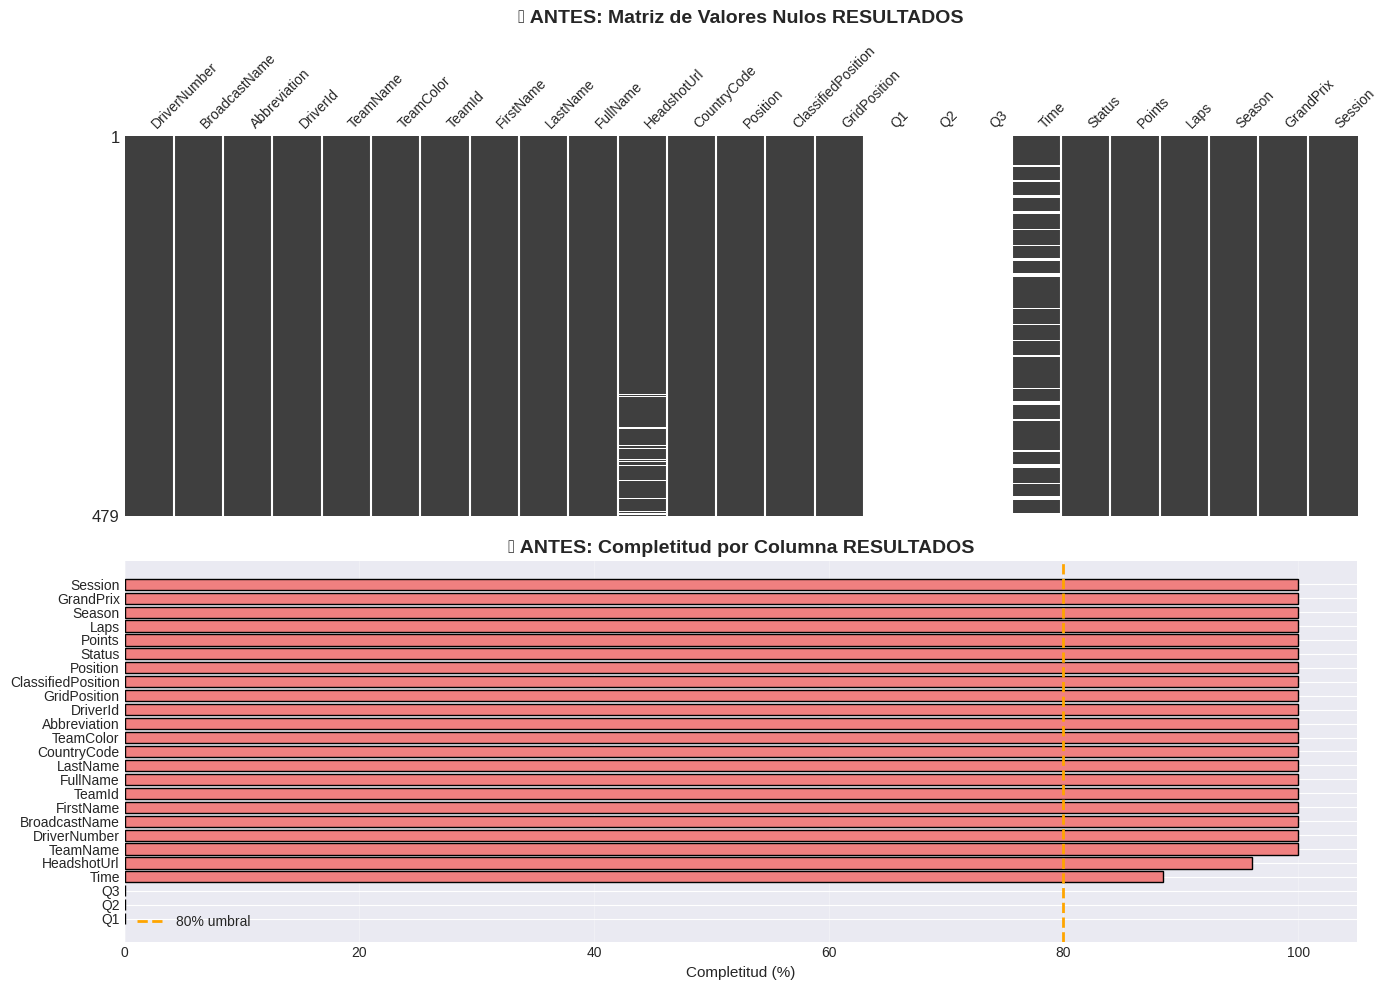


⚠️  Columnas con más del 20% de datos faltantes:
   - Q1: 479 nulos (100.0%)
   - Q2: 479 nulos (100.0%)
   - Q3: 479 nulos (100.0%)
VUELTAS 2024
Numero de registros:
24604
Numero de columnas:
33
Tipos de Datos:
GrandPrix              object
Season                  int64
Time                   object
Driver                 object
DriverNumber            int64
LapTime                object
LapNumber             float64
Stint                 float64
PitOutTime             object
PitInTime              object
Sector1Time            object
Sector2Time            object
Sector3Time            object
Sector1SessionTime     object
Sector2SessionTime     object
Sector3SessionTime     object
SpeedI1               float64
SpeedI2               float64
SpeedFL               float64
SpeedST               float64
IsPersonalBest         object
Compound               object
TyreLife              float64
FreshTyre                bool
Team                   object
LapStartTime           object
LapStar

/content/exploracion.py:56: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


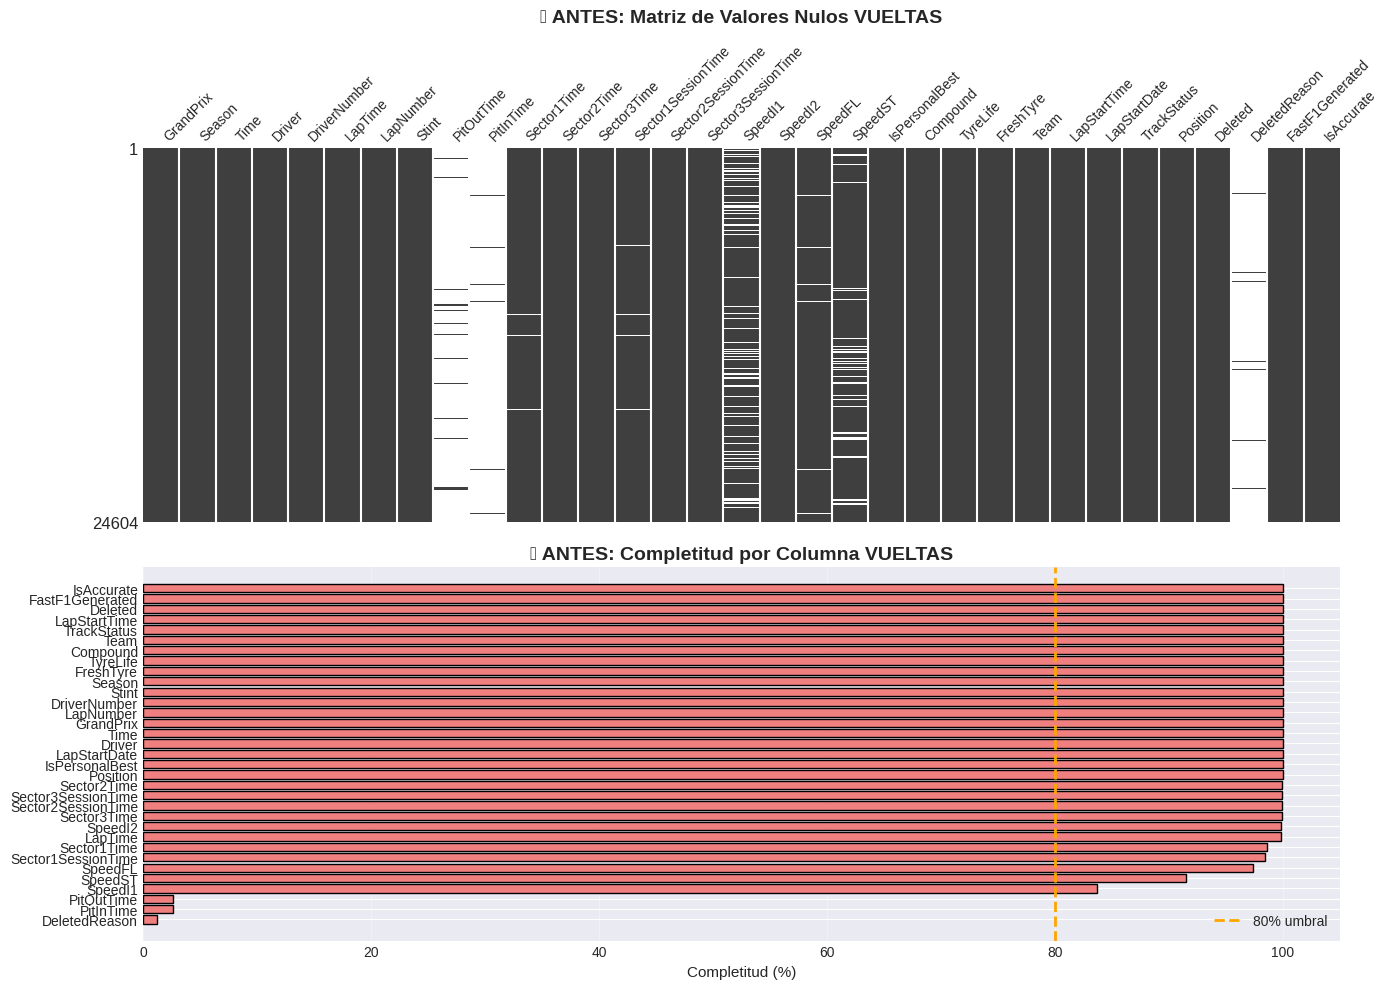


⚠️  Columnas con más del 20% de datos faltantes:
   - PitOutTime: 23955 nulos (97.4%)
   - PitInTime: 23962 nulos (97.4%)
   - DeletedReason: 24307 nulos (98.8%)
PILOTOS 2024
Numero de registros:
45
Numero de columnas:
22
Tipos de Datos:
DriverNumber            int64
BroadcastName          object
Abbreviation           object
DriverId               object
TeamName               object
TeamColor              object
TeamId                 object
FirstName              object
LastName               object
FullName               object
HeadshotUrl            object
CountryCode            object
Position              float64
ClassifiedPosition     object
GridPosition          float64
Q1                    float64
Q2                    float64
Q3                    float64
Time                   object
Status                 object
Points                float64
Laps                  float64
dtype: object
Información:
<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, 0 to 22
Data colu

/content/exploracion.py:56: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


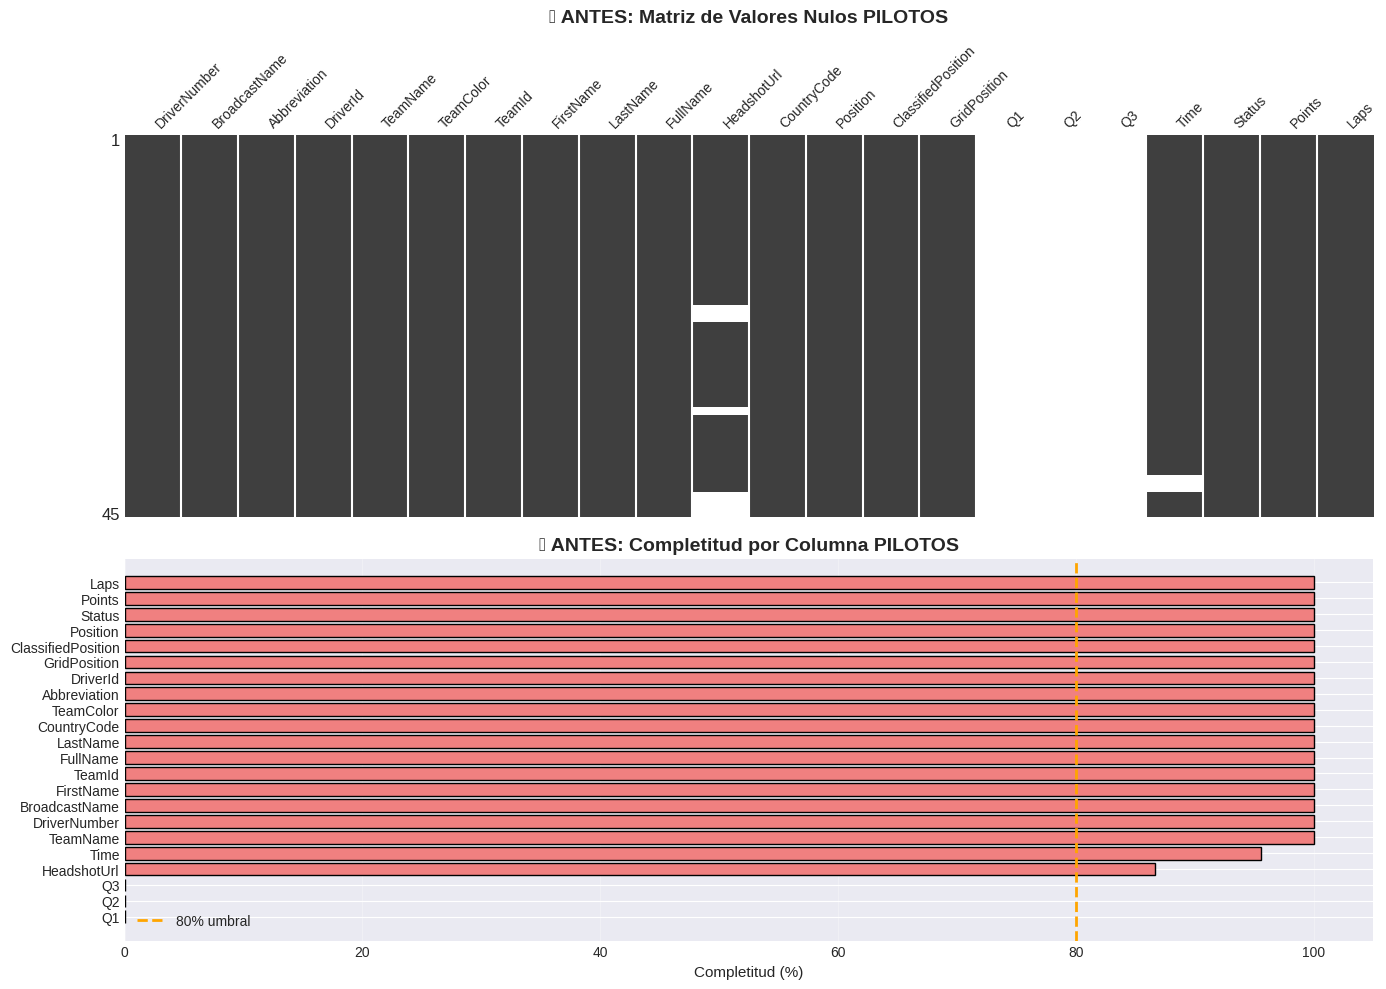


⚠️  Columnas con más del 20% de datos faltantes:
   - Q1: 45 nulos (100.0%)
   - Q2: 45 nulos (100.0%)
   - Q3: 45 nulos (100.0%)
EQUIPOS 2024
Numero de registros:
11
Numero de columnas:
3
Tipos de Datos:
TeamName     object
TeamColor    object
TeamId       object
dtype: object
Información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   TeamName   11 non-null     object
 1   TeamColor  11 non-null     object
 2   TeamId     11 non-null     object
dtypes: object(3)
memory usage: 396.0+ bytes
None

Primeras filas:
       TeamName TeamColor        TeamId
0        Alpine    ff87bc        alpine
1  Aston Martin    229971  aston_martin
2       Ferrari    e8002d       ferrari
3  Haas F1 Team    b6babd          haas
4   Kick Sauber    52e252        sauber

Estadísticas descriptivas:
        TeamName TeamColor    TeamId
count         11        11        11
u

/content/exploracion.py:56: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


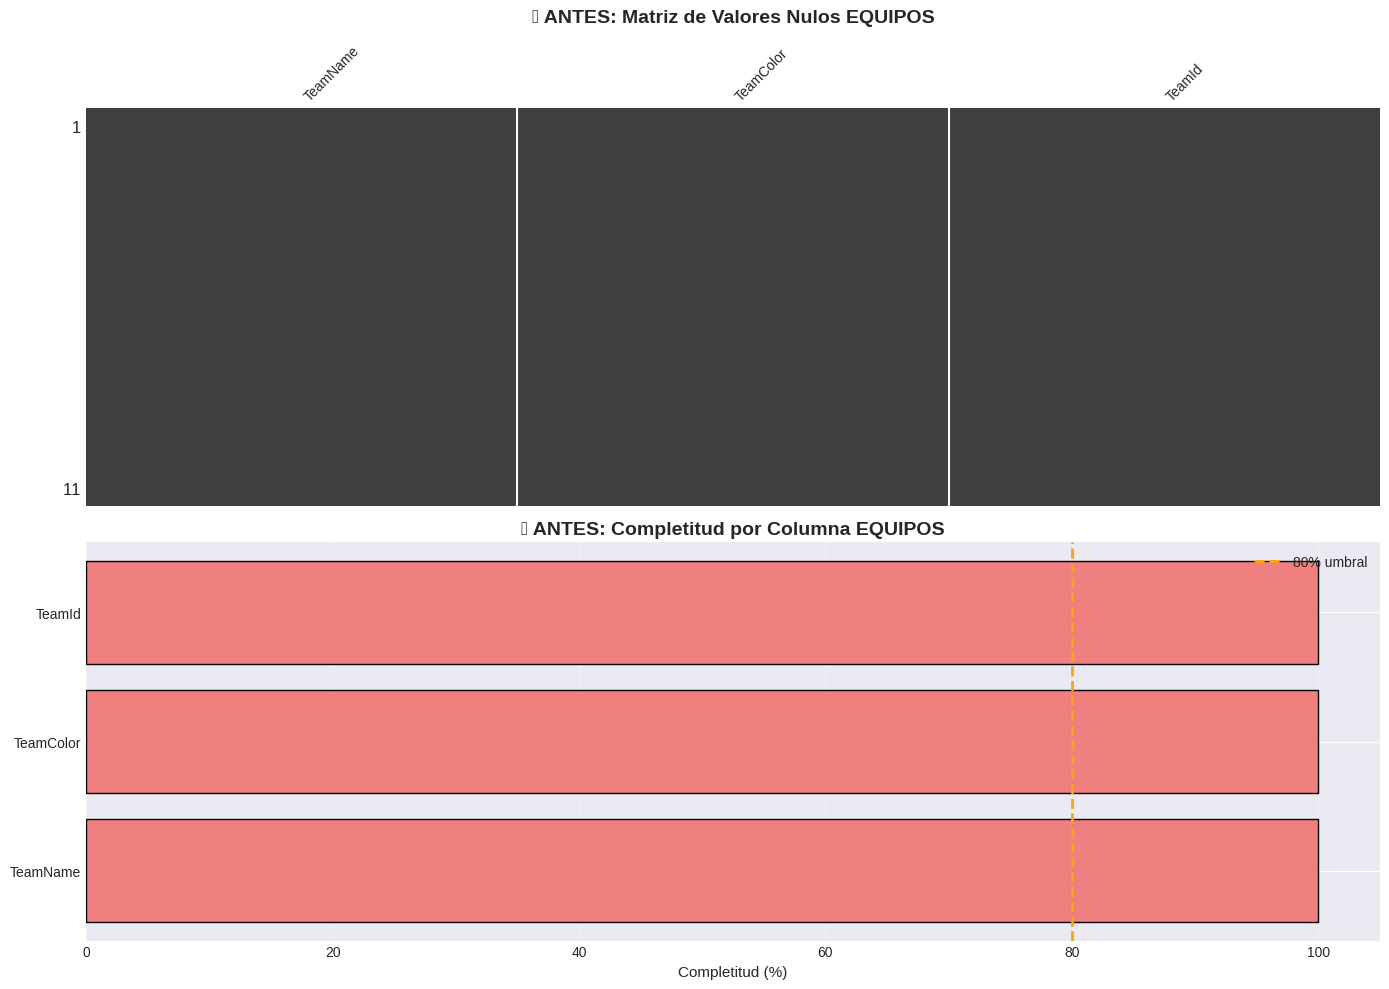


⚠️  Columnas con más del 20% de datos faltantes:
CALENDARIO 2024
Numero de registros:
25
Numero de columnas:
23
Tipos de Datos:
RoundNumber           int64
Country              object
Location             object
OfficialEventName    object
EventDate            object
EventName            object
EventFormat          object
Session1             object
Session1Date         object
Session1DateUtc      object
Session2             object
Session2Date         object
Session2DateUtc      object
Session3             object
Session3Date         object
Session3DateUtc      object
Session4             object
Session4Date         object
Session4DateUtc      object
Session5             object
Session5Date         object
Session5DateUtc      object
F1ApiSupport           bool
dtype: object
Información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0 

/content/exploracion.py:56: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


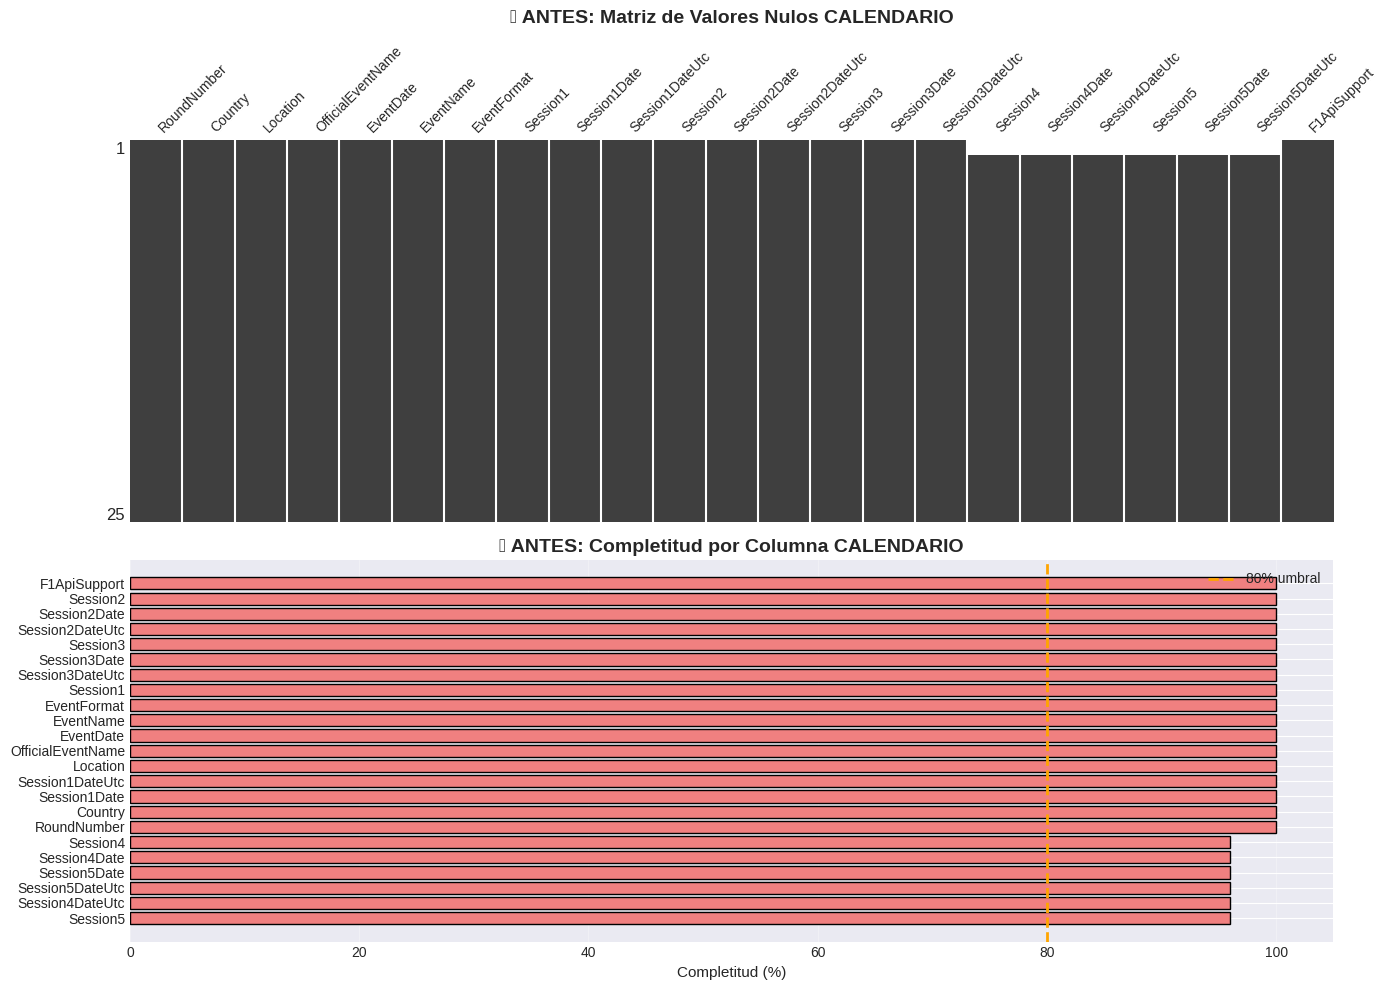


⚠️  Columnas con más del 20% de datos faltantes:


In [ ]:
dataframes = {
    "RESULTADOS": df_resultados,
    "VUELTAS":    df_laps,
    "PILOTOS":    df_pilotos,
    "EQUIPOS":    df_equipos,
    "CALENDARIO": df_calendario
}

for nombre, df in dataframes.items():
    exp.explorar_df(df, nombre)
    exp.valores_nulos(df, nombre)
    exp.filas_vacias(df)
    exp.duplicados(df)
    exp.visualizacion_outliers(df,nombre)

⏱️ **Preprocesado de tiempos**

Se convierten las columnas de tiempo (LapTime y sectores) a segundos para poder utilizarlas en el modelo.

Además:

  - 🗓️ Se transforma LapStartDate a formato datetime
  - 🧹 Se eliminan columnas irrelevantes o redundantes
  - ❌ Se eliminan filas sin LapTime (variable objetivo)

In [ ]:
cols_time = ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']
for col in cols_time:
    df_laps[col] = pd.to_timedelta(df_laps[col], errors='coerce').dt.total_seconds()

df_laps['LapStartDate'] = pd.to_datetime(df_laps['LapStartDate'], errors='coerce')

cols_drop = [
    'Time', 'PitOutTime', 'PitInTime',
    'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
    'LapStartTime', 'LapStartDate',
    'FastF1Generated', 'Deleted', 'DeletedReason'
]
df_laps = df_laps.drop(columns=cols_drop)
df_laps = df_laps.dropna(subset=['LapTime'])

📊 **Agregación de datos por carrera**

En este paso se construye un dataset a nivel piloto + Gran Premio + equipo, pasando de datos por vuelta a datos resumidos por carrera.

In [ ]:
df_race = df_laps.groupby(['Driver', 'GrandPrix', 'Team']).agg({
    'LapTime':   'mean',
    'SpeedST':   'mean',
    'TyreLife':  'mean',
    'Position':  'mean',
    'LapNumber': 'max'
}).reset_index()

df_race = df_race.dropna()

🔧 **Features de F1 (coche + circuito)**

Se crean dos tablas con información externa:

  - 🏁 Circuitos → nivel de carga aerodinámica según el trazado
  - 🏎️ Equipos → rendimiento aerodinámico de cada monoplaza

Luego:

  - 🧼 Se limpian nombres (espacios)
  - 🔗 Se unen ambas tablas a df_race mediante merge

👉 Esto añade contexto físico del coche y del circuito para mejorar el modelo

In [ ]:
df_fia_circuit = pd.DataFrame({
    'GrandPrix': [
        'Bahrain Grand Prix', 'Saudi Arabian Grand Prix', 'Australian Grand Prix',
        'Japanese Grand Prix', 'Chinese Grand Prix', 'Miami Grand Prix',
        'Emilia Romagna Grand Prix', 'Monaco Grand Prix', 'Canadian Grand Prix',
        'Spanish Grand Prix', 'Austrian Grand Prix', 'British Grand Prix',
        'Hungarian Grand Prix', 'Belgian Grand Prix', 'Dutch Grand Prix',
        'Italian Grand Prix', 'Azerbaijan Grand Prix', 'Singapore Grand Prix',
        'United States Grand Prix', 'Mexico City Grand Prix', 'São Paulo Grand Prix',
        'Las Vegas Grand Prix', 'Qatar Grand Prix', 'Abu Dhabi Grand Prix'
    ],
    'carga_aerodinamica_circuito': [
        0.30, 0.25, 0.30, 0.85, 0.90, 0.70, 0.80, 1.00, 0.30, 0.85,
        0.20, 0.80, 0.95, 0.75, 0.60, 0.10, 0.15, 0.95, 0.70, 0.25,
        0.30, 0.20, 0.25, 0.30
    ]
})

df_fia_aero = pd.DataFrame({
    'Team': [
        'Red Bull Racing', 'Mercedes', 'Ferrari', 'McLaren', 'Aston Martin',
        'Alpine', 'RB', 'Williams', 'Haas F1 Team', 'Kick Sauber'
    ],
    'carga_aerodinamica_equipo': [
        0.90, 0.85, 0.82, 0.80, 0.70, 0.65, 0.60, 0.55, 0.50, 0.50
    ]
})

df_race['Team']             = df_race['Team'].str.strip()
df_race['GrandPrix']        = df_race['GrandPrix'].str.strip()
df_fia_aero['Team']         = df_fia_aero['Team'].str.strip()
df_fia_circuit['GrandPrix'] = df_fia_circuit['GrandPrix'].str.strip()

df_race = df_race.merge(df_fia_aero,    on='Team',     how='left')
df_race = df_race.merge(df_fia_circuit, on='GrandPrix', how='left')

🧠 **Ingeniería de features (contexto F1 + rendimiento)**

En este bloque se construyen variables clave para enriquecer el modelo:

  - 📅 Se añade el orden del calendario (RoundNumber) para estructurar la temporada
  - 🏎️ Se crea el número de carrera por piloto (race_number)
  - ⚙️ Se calculan métricas de rendimiento del coche:
  - ⚡ eficiencia aerodinámica (aero_efficiency)
  - 🏁 tipo de circuito (high / medium / low)
  - 🚗 rendimiento global del coche (car_performance)
  - ⛔ penalización del coche (car_penalty)
  - 🧱 tiempo base del coche (base_car_time)

Se generan métricas históricas de pilotos y equipos:

  - 📊 ritmo histórico
  - 📈 media móvil de rendimiento
  - 📉 consistencia (desviación estándar)
  - 🧹 Se rellenan valores nulos con estadísticas del propio piloto/equipo

👉 Finalmente se imprime un resumen del dataset para comprobar que no hay valores faltantes en las variables aerodinámicas

In [ ]:
df_calendar_map = df_calendario[['EventName', 'RoundNumber']].rename(
    columns={'EventName': 'GrandPrix'}
)
df_race = df_race.merge(df_calendar_map, on='GrandPrix', how='left')
df_race = df_race.sort_values(['Driver', 'RoundNumber'])

df_race['race_number'] = df_race.groupby('Driver').cumcount() + 1

df_race['aero_efficiency'] = (
    df_race['carga_aerodinamica_equipo'] *
    df_race['carga_aerodinamica_circuito']
)
df_race['circuit_type'] = df_race['carga_aerodinamica_circuito'].apply(
    lambda x: 'high' if x > 0.8 else ('medium' if x > 0.4 else 'low')
)

df_race['driver_hist_pace'] = df_race.groupby('Driver')['LapTime'].transform(
    lambda x: x.shift(1).expanding().mean()
)
df_race['driver_rolling_pace'] = df_race.groupby('Driver')['LapTime'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)
df_race['driver_hist_consistency'] = df_race.groupby('Driver')['LapTime'].transform(
    lambda x: x.shift(1).expanding().std()
)
df_race['team_hist_pace'] = df_race.groupby('Team')['LapTime'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df_race['driver_hist_pace'] = df_race['driver_hist_pace'].fillna(
    df_race.groupby('Driver')['LapTime'].transform('mean')
)
df_race['driver_rolling_pace'] = df_race['driver_rolling_pace'].fillna(
    df_race.groupby('Driver')['LapTime'].transform('mean')
)
df_race['driver_hist_consistency'] = df_race['driver_hist_consistency'].fillna(
    df_race.groupby('Driver')['LapTime'].transform('std')
)
df_race['team_hist_pace'] = df_race['team_hist_pace'].fillna(
    df_race.groupby('Team')['LapTime'].transform('mean')
)
df_race['car_performance'] = (
    df_race['carga_aerodinamica_equipo'] * 0.7 +
    df_race['carga_aerodinamica_circuito'] * 0.3
)

df_race['base_car_time'] = (1 - df_race['carga_aerodinamica_equipo']) * 2.0
df_race['car_penalty'] = (1 - df_race['car_performance']) * 2.5

print(df_race.head())
print("Nulos aero equipo:  ", df_race['carga_aerodinamica_equipo'].isnull().sum())
print("Nulos aero circuito:", df_race['carga_aerodinamica_circuito'].isnull().sum())

   Driver                 GrandPrix      Team     LapTime     SpeedST  \
4     ALB        Bahrain Grand Prix  Williams   98.403481  299.600000   
17    ALB  Saudi Arabian Grand Prix  Williams   95.187543  322.434783   
1     ALB     Australian Grand Prix  Williams   83.943481  295.909091   
8     ALB        Chinese Grand Prix  Williams  102.874977  316.409091   
14    ALB          Miami Grand Prix  Williams   94.596160  326.920000   

     TyreLife   Position  LapNumber  carga_aerodinamica_equipo  \
4   10.185185  12.962963       56.0                       0.55   
17  20.826087  14.021739       50.0                       0.55   
1   11.981481  12.407407       55.0                       0.55   
8   14.204545  13.340909       56.0                       0.55   
14  17.720000  15.400000       57.0                       0.55   

    carga_aerodinamica_circuito  ...  race_number  aero_efficiency  \
4                          0.30  ...            1           0.1650   
17                      

🏎️** Preparación de features + entrenamiento del modelo**

Se construye el dataset final para el modelo de predicción de tiempos de vuelta ⏱️:

  - 📌 Se seleccionan variables numéricas y categóricas relevantes (coche, piloto, equipo y circuito)
  - 🧹 Se eliminan filas con valores nulos
  - 🔄 Se aplica One-Hot Encoding a variables categóricas
  - ✂️ Se separa en X (features) e y (LapTime)

Luego:

  - 🧪 Se divide el dataset en train/test
  - 🚀 Se entrena un modelo XGBoost Regressor
  - 📉 Se evalúa con MAE (error medio absoluto en segundos)
  - 📊 Se analiza la importancia de variables para entender qué influye más en el rendimiento

👉 Resultado: modelo entrenado para predecir tiempos de vuelta con variables físicas, históricas y contextuales

In [ ]:
FEATURES_NUMERICAS = [
    # 🏎️ COCHE (MÁS IMPORTANTE AHORA)
    'car_performance',
    'car_penalty',
    'carga_aerodinamica_equipo',
    'carga_aerodinamica_circuito',
    'aero_efficiency',

    # 📊 RENDIMIENTO EN PISTA
    'SpeedST',
    'TyreLife',
    'LapNumber',

    # 🏁 CONTEXTO TEMPORAL
    'race_number',

    # 👤 PILOTO (HISTÓRICO)
    'driver_hist_pace',
    'driver_rolling_pace',
    'driver_hist_consistency',

    # 🏭 EQUIPO (HISTÓRICO)
    'team_hist_pace',
]
FEATURES_CATEGORICAS = ['Driver', 'Team', 'GrandPrix', 'circuit_type']

df_model_base = df_race[FEATURES_NUMERICAS + FEATURES_CATEGORICAS + ['LapTime']].copy()
df_model_base = df_model_base.dropna()

df_model = pd.get_dummies(df_model_base, columns=FEATURES_CATEGORICAS)

obj_cols = df_model.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print(f"Columnas object eliminadas: {obj_cols}")
    df_model = df_model.drop(columns=obj_cols)

X = df_model.drop(columns=['LapTime'])
y = df_model['LapTime']

print(f"\nFeatures usadas en el modelo: {X.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
print(f"MAE en test: {mae:.4f} segundos")

feat_imp = pd.Series(model.feature_importances_, index=X.columns)
print("\nTop 15 features más importantes:")
print(feat_imp.sort_values(ascending=False).head(15))


Features usadas en el modelo: 73
MAE en test: 1.0596 segundos

Top 15 features más importantes:
LapNumber                              0.308609
carga_aerodinamica_circuito            0.099043
GrandPrix_Miami Grand Prix             0.096717
GrandPrix_Singapore Grand Prix         0.074021
GrandPrix_United States Grand Prix     0.055478
GrandPrix_Dutch Grand Prix             0.042969
GrandPrix_Australian Grand Prix        0.036990
GrandPrix_Emilia Romagna Grand Prix    0.032411
GrandPrix_Azerbaijan Grand Prix        0.030146
GrandPrix_Las Vegas Grand Prix         0.030092
race_number                            0.028589
GrandPrix_Canadian Grand Prix          0.027208
driver_hist_pace                       0.023513
GrandPrix_Qatar Grand Prix             0.017739
GrandPrix_Abu Dhabi Grand Prix         0.015925
dtype: float32


📊 **Parrilla 2025 + penalización de adaptación**

En este bloque se prepara la configuración de la temporada 2025 y se modela el efecto de adaptación de los pilotos:

  - 👨‍✈️🏎️ Se construye el mapa piloto → equipo para 2024 y 2025
  - 🆕 Se define la parrilla 2025 con cambios de equipo y nuevos pilotos

Luego se introduce un modelo de rendimiento más realista:

  - 🧑‍🎓 Rookies → penalización alta inicial
  - 🔄 Cambios de equipo → penalización media
  - 🧠 Pilotos estables → sin penalización
  - 📉 La penalización disminuye progresivamente con las carreras (decadencia exponencial)

Además:

  - 🧮 Se imprime una tabla con la penalización por carrera
  - 🏎️ Se muestra la parrilla 2025 con su categoría (rookie / cambio / estable)

👉 Objetivo: simular la adaptación real de pilotos a nuevos coches durante la temporada

In [ ]:
driver_team_2024 = df_race.groupby('Driver')['Team'].first().to_dict()

driver_team_2025 = {
    'SAI': 'Williams',
    'HAM': 'Ferrari',
    'RUS': 'Mercedes',
    'ANT': 'Mercedes',
    'LEC': 'Ferrari',
    'NOR': 'McLaren',
    'PIA': 'McLaren',
    'VER': 'Red Bull Racing',
    'LAW': 'Red Bull Racing',
    'ALO': 'Aston Martin',
    'STR': 'Aston Martin',
    'GAS': 'Alpine',
    'DOO': 'Alpine',
    'ALB': 'Williams',
    'TSU': 'RB',
    'HAD': 'RB',
    'BEA': 'Haas F1 Team',
    'OCO': 'Haas F1 Team',
    'BOT': 'Kick Sauber',
    'HUL': 'Kick Sauber',
}




PENALTY_ROOKIE      = 1.5   # segundos extra al principio para rookies
PENALTY_TEAM_CHANGE = 0.6   # segundos extra al principio para cambios de equipo
DECAY_RACES         = 8     # en ~8 carreras la penalización cae a <5%

rookies      = {'ANT', 'HAD', 'DOO', 'BEA'}          # nunca han corrido en F1
team_changes = {'SAI', 'HAM', 'LAW', 'HUL', 'OCO'}   # veteranos que cambian de equipo

def adaptation_penalty(driver, race_number):
    """
    Devuelve los segundos de penalización por adaptación al coche.
    Decrece exponencialmente: penalty * exp(-race_number / decay)
    """
    if driver in rookies:
        base = PENALTY_ROOKIE
    elif driver in team_changes:
        base = PENALTY_TEAM_CHANGE
    else:
        return 0.0

    decay = DECAY_RACES / np.log(20)
    return base * np.exp(-race_number / decay)

print("\n=== PENALIZACIÓN DE ADAPTACIÓN (segundos extra) ===")
print(f"{'Carrera':>8}", end="")
for d in sorted(rookies | team_changes):
    print(f"  {d:>6}", end="")
print()
for r in range(1, 11):
    print(f"{r:>8}", end="")
    for d in sorted(rookies | team_changes):
        print(f"  {adaptation_penalty(d, r):>6.3f}", end="")
    print()

print("\n=== PARRILLA 2025 ===")
for driver, team in sorted(driver_team_2025.items(), key=lambda x: x[1]):
    categoria = "ROOKIE" if driver in rookies else \
                "CAMBIO EQUIPO" if driver in team_changes else "mismo equipo"
    print(f"  {driver:4s} → {team:20s} [{categoria}]")


=== PENALIZACIÓN DE ADAPTACIÓN (segundos extra) ===
 Carrera     ANT     BEA     DOO     HAD     HAM     HUL     LAW     OCO     SAI
       1   1.031   1.031   1.031   1.031   0.413   0.413   0.413   0.413   0.413
       2   0.709   0.709   0.709   0.709   0.284   0.284   0.284   0.284   0.284
       3   0.488   0.488   0.488   0.488   0.195   0.195   0.195   0.195   0.195
       4   0.335   0.335   0.335   0.335   0.134   0.134   0.134   0.134   0.134
       5   0.231   0.231   0.231   0.231   0.092   0.092   0.092   0.092   0.092
       6   0.159   0.159   0.159   0.159   0.063   0.063   0.063   0.063   0.063
       7   0.109   0.109   0.109   0.109   0.044   0.044   0.044   0.044   0.044
       8   0.075   0.075   0.075   0.075   0.030   0.030   0.030   0.030   0.030
       9   0.052   0.052   0.052   0.052   0.021   0.021   0.021   0.021   0.021
      10   0.035   0.035   0.035   0.035   0.014   0.014   0.014   0.014   0.014

=== PARRILLA 2025 ===
  GAS  → Alpine               [mi

📊 **Construcción del dataset de simulación 2025**

En este bloque se crea el dataset completo para simular la temporada 2025:

  - 🗓️ Se filtran los Grand Prix reales del calendario, eliminando tests y pre-season
  - 👨‍✈️🏎️ Se generan todas las combinaciones piloto × carrera × equipo
  - 🔢 Se asigna el orden de cada carrera (race_number) según el calendario

Luego se enriquece el dataset:

  - 🏁 Se añaden variables de circuito y aerodinámica del equipo
  - ⚙️ Se calculan métricas como:
    - eficiencia aerodinámica
    - tipo de circuito (high / medium / low)
  - 📊 Se incorporan estadísticas históricas de 2024:
    - ritmo medio de piloto y equipo
    - consistencia
    - media móvil reciente
  - 🆕 Para rookies se usa el rendimiento del equipo como referencia inicial
  - 🧹 Se rellenan valores faltantes con medias globales

Finalmente:

  - 🔄 Se aplican one-hot encodings igual que en entrenamiento
  - 🧩 Se alinean columnas con el modelo entrenado
  - 🚀 Se generan las predicciones base del modelo para 2025

👉 Resultado: dataset listo para simular toda la temporada 2025 con el modelo entrenado

In [ ]:
gps_2025 = [
    gp for gp in df_calendario['EventName'].unique()
    if 'pre-season' not in gp.lower() and 'testing' not in gp.lower()
]
gps_ordenados = [
    gp for gp in df_calendario['EventName'].tolist()
    if 'pre-season' not in gp.lower() and 'testing' not in gp.lower()
]

print(f"\nGPs en simulación 2025: {len(gps_2025)}")

# Combinaciones piloto × GP
df_2025_list = []
for driver, team in driver_team_2025.items():
    for gp in gps_2025:
        df_2025_list.append([driver, gp, team])

df_2025 = pd.DataFrame(df_2025_list, columns=['Driver', 'GrandPrix', 'Team'])

calendar_order_2025 = {gp: i + 1 for i, gp in enumerate(gps_ordenados)}
df_2025['race_number'] = df_2025['GrandPrix'].map(calendar_order_2025)

# Features del circuito
df_2025 = df_2025.merge(df_fia_circuit, on='GrandPrix', how='left')
df_2025 = df_2025.merge(df_fia_aero,    on='Team',      how='left')

df_2025['aero_efficiency'] = (
    df_2025['carga_aerodinamica_equipo'] *
    df_2025['carga_aerodinamica_circuito']
)
df_2025['circuit_type'] = df_2025['carga_aerodinamica_circuito'].apply(
    lambda x: 'high' if x > 0.8 else ('medium' if x > 0.4 else 'low')
)


# Histórico piloto/equipo al cierre de 2024
driver_hist = df_race.groupby('Driver').agg(
    driver_hist_pace        = ('LapTime', 'mean'),
    driver_rolling_pace     = ('LapTime', lambda x: x.tail(3).mean()),
    driver_hist_consistency = ('LapTime', 'std'),
).reset_index()

team_hist = df_race.groupby('Team').agg(
    team_hist_pace = ('LapTime', 'mean'),
).reset_index()

global_mean_pace = df_race['LapTime'].mean()
global_mean_std  = df_race['LapTime'].std()

df_2025 = df_2025.merge(driver_hist, on='Driver', how='left')
df_2025 = df_2025.merge(team_hist,   on='Team',   how='left')

# Rookies: usar media del equipo donde debutan
for rookie in rookies:
    mask = df_2025['Driver'] == rookie
    if mask.any():
        team_rookie   = driver_team_2025[rookie]
        team_pace_val = team_hist.loc[
            team_hist['Team'] == team_rookie, 'team_hist_pace'
        ].values
        team_pace_val = team_pace_val[0] if len(team_pace_val) > 0 else global_mean_pace
        df_2025.loc[mask, 'driver_hist_pace']        = team_pace_val
        df_2025.loc[mask, 'driver_rolling_pace']     = team_pace_val
        df_2025.loc[mask, 'driver_hist_consistency'] = global_mean_std

df_2025['driver_hist_pace']        = df_2025['driver_hist_pace'].fillna(global_mean_pace)
df_2025['driver_rolling_pace']     = df_2025['driver_rolling_pace'].fillna(global_mean_pace)
df_2025['driver_hist_consistency'] = df_2025['driver_hist_consistency'].fillna(global_mean_std)



# Features físicas del circuito
gp_hist = df_race.groupby('GrandPrix').agg(
    SpeedST   = ('SpeedST',  'mean'),
    TyreLife  = ('TyreLife', 'mean'),
    LapNumber = ('LapNumber','mean'),
).reset_index()

df_2025 = df_2025.merge(gp_hist, on='GrandPrix', how='left')




# One-hot encoding
df_2025_model = pd.get_dummies(
    df_2025, columns=['Driver', 'Team', 'GrandPrix', 'circuit_type']
)

missing_cols = set(X_train.columns) - set(df_2025_model.columns)
for c in missing_cols:
    df_2025_model[c] = 0

extra_cols = set(df_2025_model.columns) - set(X_train.columns)
df_2025_model = df_2025_model.drop(columns=list(extra_cols))
df_2025_model = df_2025_model[X_train.columns]

# Predicción base
pred_2025 = model.predict(df_2025_model)



GPs en simulación 2025: 24


🏁 **Simulación de carrera + campeonato 2025**

En este bloque se genera el resultado final de la temporada simulada:

  - 🎲 Se añade ruido aleatorio para representar incertidumbre real de carrera
  - 🧠 Se aplica la penalización de adaptación de pilotos (rookies y cambios de equipo)

In [ ]:
np.random.seed(42)

ruido = np.random.normal(loc=0, scale=mae * 0.2)

# Penalización de adaptación vectorizada
penalizacion = df_2025.apply(
    lambda row: adaptation_penalty(row['Driver'], row['race_number']), axis=1
).values

df_2025['PredLapTime'] = pred_2025 + ruido + penalizacion

# Diagnóstico
print("\n=== VARIACIÓN PredLapTime por piloto ===")
diag = df_2025.groupby('Driver')['PredLapTime'].agg(['mean', 'std', 'min', 'max'])
print(diag.sort_values('mean'))

# Ranking y puntos
df_2025['PositionSim'] = df_2025.groupby('GrandPrix')['PredLapTime'].rank(method='min')

points_map = {1: 25, 2: 18, 3: 15, 4: 12, 5: 10, 6: 8, 7: 6, 8: 4, 9: 2, 10: 1}
df_2025['Points'] = df_2025['PositionSim'].map(points_map).fillna(0)

championship_2025 = df_2025.groupby('Driver')['Points'].sum().sort_values(ascending=False)
print("\n=== CAMPEONATO SIMULADO 2025 ===")
print(championship_2025)


=== VARIACIÓN PredLapTime por piloto ===
             mean        std        min         max
Driver                                             
HUL     91.162229   7.803799  73.264356  101.102497
BOT     91.238096   7.837917  73.280060  101.327034
HAD     91.238946   7.935882  73.255940  100.905623
BEA     91.354189   7.978520  73.322377  101.137618
STR     91.492158   8.172801  73.026260  101.603676
ALB     91.550255   8.112806  73.181183  101.062698
GAS     91.586066   8.163065  73.156647  101.164383
OCO     91.675215   8.085679  73.388349  100.681213
TSU     91.685367   8.194298  73.332962  101.088570
DOO     91.729817   8.277174  73.376179  101.171271
VER     92.745226  10.276305  72.841522  110.098907
LEC     92.753215  10.218337  72.868431  109.396385
HAM     92.819998  10.312528  72.870221  109.994795
NOR     92.831340  10.343121  72.798508  110.137184
RUS     92.898297  10.284779  72.952133  110.092773
PIA     92.924745  10.289181  72.964844  110.129219
ANT     92.956642  10.

🏁 **Evolución del campeonato 2025 (simulado)**

En este bloque se visualiza cómo evoluciona el campeonato de pilotos a lo largo de la temporada 2025:

  - 🧹 Se eliminan duplicados por piloto y carrera
  - 🗓️ Se ordenan las carreras según el calendario oficial
  - 📊 Se calculan los puntos acumulados (cumulative points) por piloto

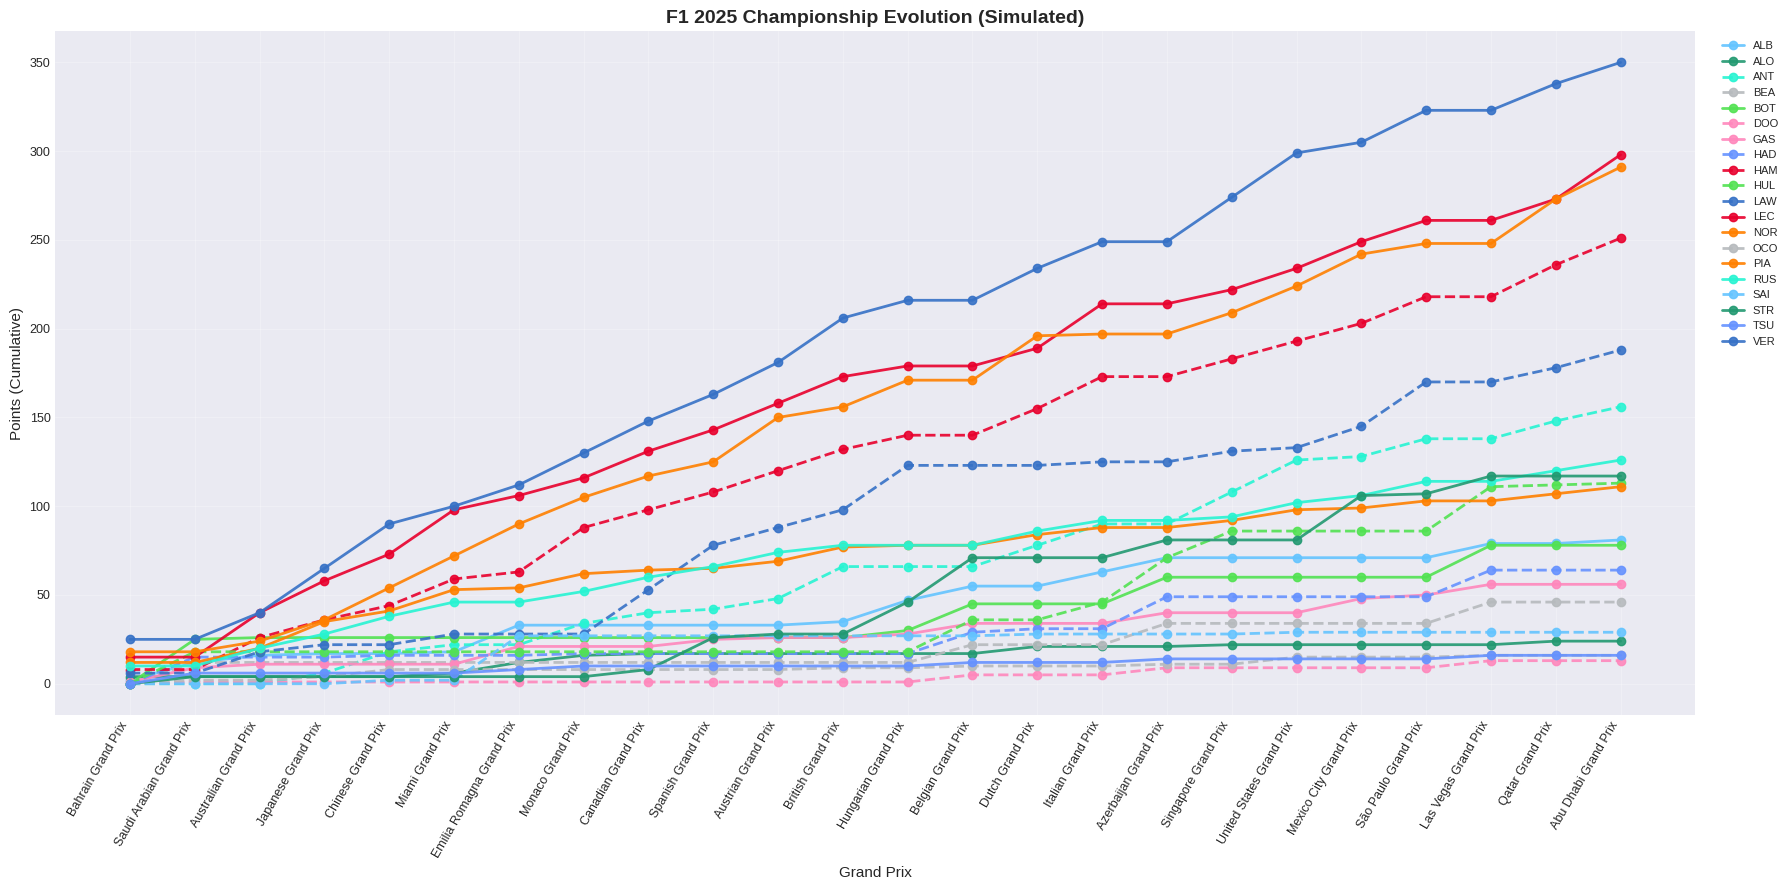

In [ ]:
df_2025 = df_2025.drop_duplicates(subset=['GrandPrix', 'Driver'])
df_2025['GP_order'] = df_2025['GrandPrix'].map(calendar_order_2025)
df_2025 = df_2025.sort_values(['Driver', 'GP_order'])
df_2025['CumulativePoints'] = df_2025.groupby('Driver')['Points'].cumsum()

df_plot = df_2025.pivot(index='GrandPrix', columns='Driver', values='CumulativePoints')
df_plot = df_plot.reindex(gps_ordenados)

team_colors = {
    'Red Bull Racing': '#3671C6',
    'Mercedes':        '#27F4D2',
    'Ferrari':         '#E8002D',
    'McLaren':         '#FF8000',
    'Aston Martin':    '#229971',
    'Alpine':          '#FF87BC',
    'RB':              '#6692FF',
    'Williams':        '#64C4FF',
    'Haas F1 Team':    '#B6BABD',
    'Kick Sauber':     '#52E252',
}
driver_color_map = {
    driver: team_colors.get(team, '#888888')
    for driver, team in driver_team_2025.items()
}

plt.figure(figsize=(18, 9))
for driver in df_plot.columns:
    color    = driver_color_map.get(driver, '#888888')
    # Línea discontinua para rookies y cambios de equipo
    linestyle = '--' if driver in (rookies | team_changes) else '-'
    plt.plot(
        df_plot.index,
        df_plot[driver],
        marker='o',
        label=driver,
        color=color,
        linewidth=2,
        linestyle=linestyle,
        alpha=0.9
    )

plt.xticks(rotation=60, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.xlabel('Grand Prix', fontsize=11)
plt.ylabel('Points (Cumulative)', fontsize=11)
plt.title(
    'F1 2025 Championship Evolution (Simulated)',
    fontsize=14,
    fontweight='bold'
)

plt.grid(alpha=0.25)
plt.legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=8,
    frameon=False
)
plt.tight_layout()
plt.savefig('campeonato_2025_simulado.png', dpi=150, bbox_inches='tight')
plt.show()

🏁 **Procesamiento de datos reales 2025**

En este bloque se trabaja con los resultados reales de la temporada 2025:

  - 📥 Se carga el dataset con posiciones reales por carrera
  - 🏆 Se convierten posiciones en puntos oficiales de F1 (25–1)
  - 🗓️ Se asigna el orden del calendario para mantener la secuencia correcta
  - 📊 Se calculan los puntos acumulados por piloto a lo largo de la temporada

Finalmente:

  - 🔄 Se reorganizan los datos en formato matriz piloto vs Gran Premio
  - 📈 Se prepara el dataset para poder comparar la evolución real del campeonato

👉 Resultado: base lista para comparar simulación vs realidad

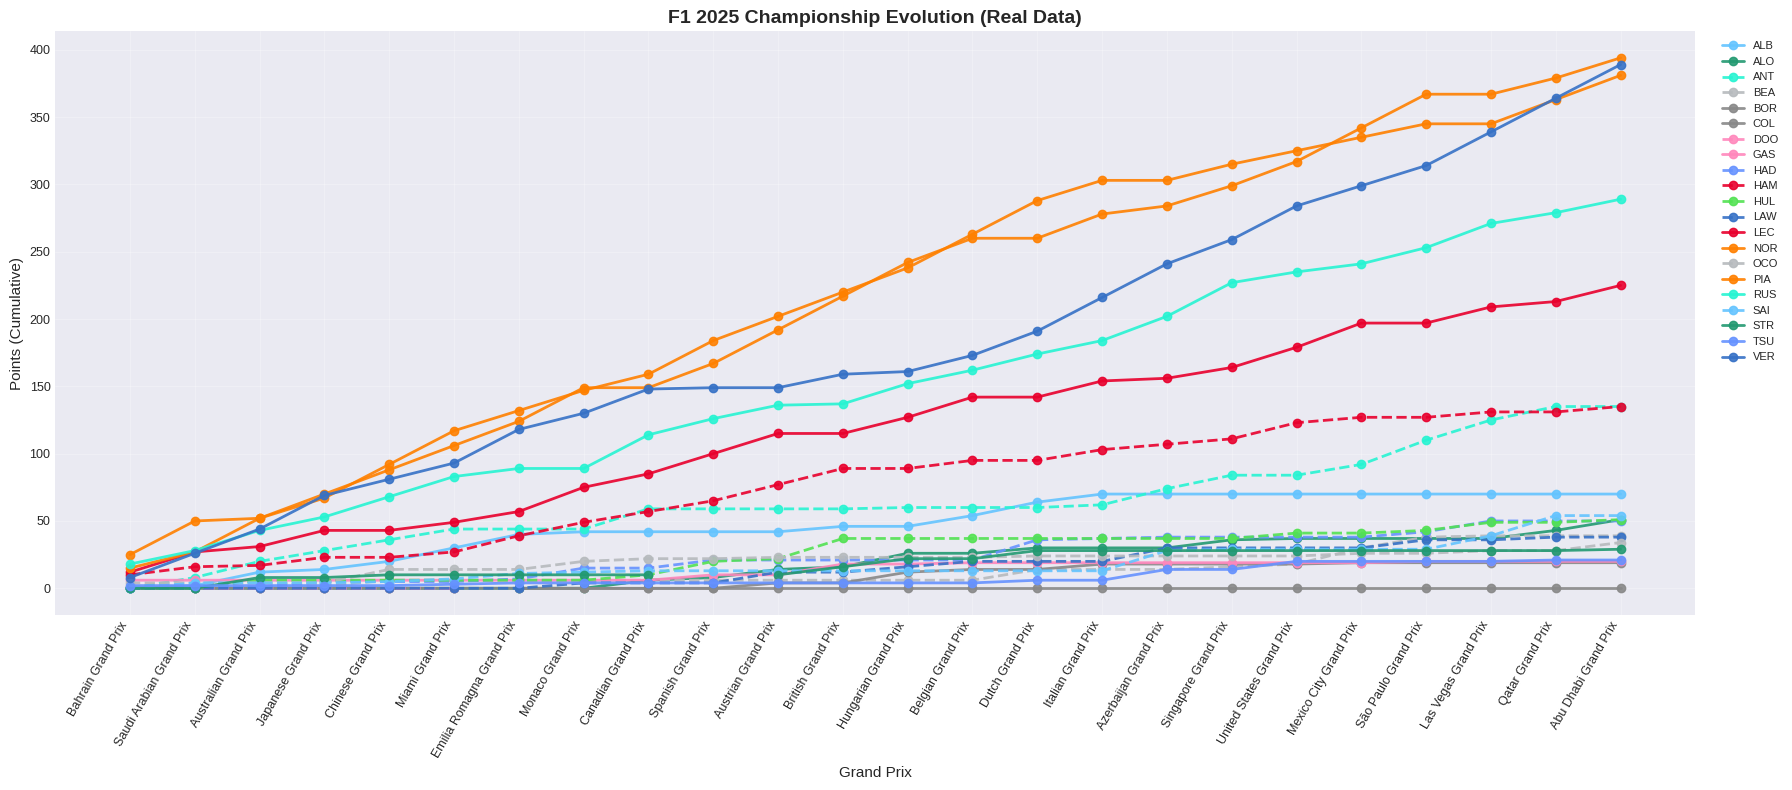

In [ ]:
df_real_2025 = pd.read_csv("resultados_2025.csv")

# puntos reales
points_map = {1: 25, 2: 18, 3: 15, 4: 12, 5: 10, 6: 8, 7: 6, 8: 4, 9: 2, 10: 1}
df_real_2025['Points'] = df_real_2025['Position'].map(points_map).fillna(0)

# ordenar GP
df_real_2025['GP_order'] = df_real_2025['GrandPrix'].map(calendar_order_2025)
df_real_2025 = df_real_2025.sort_values(['Driver', 'GP_order'])
df_real_2025['CumulativePoints'] = df_real_2025.groupby('Driver')['Points'].cumsum()

df_real_plot = df_real_2025.pivot(
    index='GrandPrix',
    columns='Driver',
    values='CumulativePoints'
).reindex(gps_ordenados)

plt.figure(figsize=(18, 8))

for driver in df_real_plot.columns:
    color = driver_color_map.get(driver, '#888888')
    linestyle = '--' if driver in (rookies | team_changes) else '-'

    plt.plot(
        df_real_plot.index,
        df_real_plot[driver],
        marker='o',
        label=driver,
        color=color,
        linestyle=linestyle,
        linewidth=2,
        alpha=0.9
    )



plt.xticks(rotation=60, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.xlabel("Grand Prix", fontsize=11)
plt.ylabel("Points (Cumulative)", fontsize=11)
plt.title(
    "F1 2025 Championship Evolution (Real Data)",
    fontsize=14,
    fontweight='bold'
)
plt.legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=8,
    frameon=False
)
plt.tight_layout()
plt.grid(alpha=0.25)
plt.savefig('campeonato_2025_real.png', dpi=150, bbox_inches='tight')
plt.show()